In [1]:
!pip install plotly

In [2]:
!pip install nbformat --upgrade

In [3]:
import pandas as pd 
from datetime import datetime as dt, timedelta
import plotly.express as px
import plotly.graph_objects as go 
import plotly.colors 

Data Exploration

In [4]:
data=pd.read_csv("D:\Customer-Segmentation\online_retail_II.csv.zip")
data.head()
data.describe()


,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [5]:
data.describe(include='O')

,Invoice,StockCode,Description,InvoiceDate,Country
count,1067371,1067371,1062989,1067371,1067371
unique,53628,5305,5698,47635,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2010-12-06 16:57:00,United Kingdom
freq,1350,5829,5918,1350,981330


In [6]:
# Finding Null values
data[data["Customer ID"].isna()].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom


In [7]:
data[data["Quantity"]<0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [8]:
data["Invoice"] = data["Invoice"].astype(str)
data[data["Invoice"].str.match("^\\d{6}$")==False]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [9]:
data["Invoice"].str.replace("0-9","",regex=True).unique()

array(['489434', '489435', '489436', ..., '581585', '581586', '581587'],
      shape=(53628,), dtype=object)

In [10]:
data[data["Invoice"].str.startswith("A")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825443,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [11]:
# check if stockcode has 5 values
data["StockCode"]=data["StockCode"].astype(str)
data[(data["StockCode"].str.match("^\\d{5}$")== False)&(data["StockCode"].str.match("^\\d{5}[a-zA-Z]+$")==False)]["StockCode"].unique()

array(['POST', 'D', 'DCGS0058', 'DCGS0068', 'DOT', 'M', 'DCGS0004',
       'DCGS0076', 'C2', 'BANK CHARGES', 'DCGS0003', 'TEST001',
       'gift_0001_80', 'DCGS0072', 'gift_0001_20', 'DCGS0044', 'TEST002',
       'gift_0001_10', 'gift_0001_50', 'DCGS0066N', 'gift_0001_30',
       'PADS', 'ADJUST', 'gift_0001_40', 'gift_0001_60', 'gift_0001_70',
       'gift_0001_90', 'DCGSSGIRL', 'DCGS0006', 'DCGS0016', 'DCGS0027',
       'DCGS0036', 'DCGS0039', 'DCGS0060', 'DCGS0056', 'DCGS0059', 'GIFT',
       'DCGSLBOY', 'm', 'DCGS0053', 'DCGS0062', 'DCGS0037', 'DCGSSBOY',
       'DCGSLGIRL', 'S', 'DCGS0069', 'DCGS0070', 'DCGS0075', 'B',
       'DCGS0041', 'ADJUST2', '47503J ', 'C3', 'SP1002', 'AMAZONFEE',
       'DCGS0055', 'DCGS0074', 'DCGS0057', 'DCGS0073', 'DCGS0071',
       'DCGS0066P', 'DCGS0067', 'CRUK'], dtype=object)

In [12]:
# check all values if it is ligide value or not ,customer id null or not
data[data["StockCode"].str.contains("^DOT")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
2379,489597,DOT,DOTCOM POSTAGE,1,2009-12-01 14:28:00,647.19,NaN,United Kingdom
2539,489600,DOT,DOTCOM POSTAGE,1,2009-12-01 14:43:00,55.96,NaN,United Kingdom
2551,489601,DOT,DOTCOM POSTAGE,1,2009-12-01 14:44:00,68.39,NaN,United Kingdom
2571,489602,DOT,DOTCOM POSTAGE,1,2009-12-01 14:45:00,59.35,NaN,United Kingdom
2619,489603,DOT,DOTCOM POSTAGE,1,2009-12-01 14:46:00,42.39,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
1062295,581219,DOT,DOTCOM POSTAGE,1,2011-12-08 09:28:00,1008.96,NaN,United Kingdom
1062715,581238,DOT,DOTCOM POSTAGE,1,2011-12-08 10:53:00,1683.75,NaN,United Kingdom
1064829,581439,DOT,DOTCOM POSTAGE,1,2011-12-08 16:30:00,938.59,NaN,United Kingdom
1066369,581492,DOT,DOTCOM POSTAGE,1,2011-12-09 10:03:00,933.17,NaN,United Kingdom


Data Cleaning

In [13]:
# clean Invoice column
data["Invoice"] = data["Invoice"].astype("str")
mask=(
    data["Invoice"].str.match("^\\d{6}$")==True
)
data=data[mask]
data

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [14]:
#clean stockcode
data["StockCode"]=data["StockCode"].astype("str")
mask=(
    (data["StockCode"].str.match("^\\d{5}$")==True)
    |(data["StockCode"].str.match("^\\d{5}[a-zA-Z]+$")==True)
    |(data["StockCode"].str.match("^PADS$")==True)
)
data=data[mask]
data

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067365,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [15]:
data.dropna(subset=['Customer ID'],inplace=True)

C:\Users\Pasupathi\AppData\Local\Temp\ipykernel_15856\2376444423.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(subset=['Customer ID'],inplace=True)


In [16]:
data.describe()

,Quantity,Price,Customer ID
count,802711.000000,802711.000000,802711.000000
mean,13.336280,2.930474,15338.065410
std,144.542222,4.275804,1693.929085
min,1.000000,0.000000,12346.000000
25%,2.000000,1.250000,13988.000000
50%,5.000000,1.950000,15276.000000
75%,12.000000,3.750000,16809.000000
max,80995.000000,649.500000,18287.000000


In [17]:
# check price
len(data[data["Price"]==0.0])

62

In [18]:
data=data[data["Price"]>0]
data.describe()
data["Price"].min()

0.001

FEATURE ENGINEERING

In [19]:

data['TotalAmount']=data['Quantity']*data['Price']

C:\Users\Pasupathi\AppData\Local\Temp\ipykernel_15856\2180465194.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['TotalAmount']=data['Quantity']*data['Price']


In [20]:
# creating monetary and frequency
rfm=data.groupby(by='Customer ID',as_index=False).agg(
    Monetary = ("TotalAmount","sum"),
    Frequency = ("Invoice","nunique"),
    LastInvoiceDate = ("InvoiceDate","max")
)
rfm.head()

,Customer ID,Monetary,Frequency,LastInvoiceDate
0,12346.0,77352.96,3,2011-01-18 10:01:00
1,12347.0,5633.32,8,2011-12-07 15:52:00
2,12348.0,1658.40,5,2011-09-25 13:13:00
3,12349.0,3678.69,3,2011-11-21 09:51:00
4,12350.0,294.40,1,2011-02-02 16:01:00


In [21]:
# creating Recency by (max invoice date - last invoice date)
rfm["LastInvoiceDate"]=pd.to_datetime(rfm["LastInvoiceDate"])
Max_invoice_date = rfm["LastInvoiceDate"].max()
rfm["Recency"]= (Max_invoice_date - rfm["LastInvoiceDate"]).dt.days
rfm.head()

,Customer ID,Monetary,Frequency,LastInvoiceDate,Recency
0,12346.0,77352.96,3,2011-01-18 10:01:00,325
1,12347.0,5633.32,8,2011-12-07 15:52:00,1
2,12348.0,1658.40,5,2011-09-25 13:13:00,74
3,12349.0,3678.69,3,2011-11-21 09:51:00,18
4,12350.0,294.40,1,2011-02-02 16:01:00,309


In [22]:
# check the distribution of data and outliers by using hisotgram
import matplotlib.pyplot as plt
import seaborn as sns

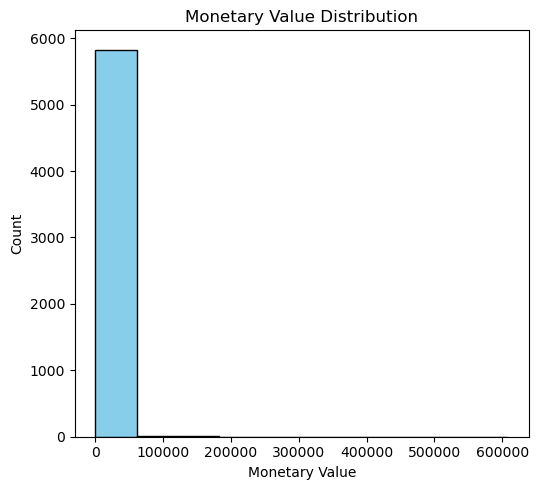

In [45]:
 #check the distribution of data and outliers by using hisotgram
plt.figure(figsize=(15,5))
# Monetary Value Distribution
plt.subplot(1,3,1)
plt.hist(rfm["Monetary"],bins=10,color="skyblue",edgecolor="black")
plt.title("Monetary Value Distribution")
plt.xlabel("Monetary Value")
plt.ylabel("Count")

plt.tight_layout()
plt.show()



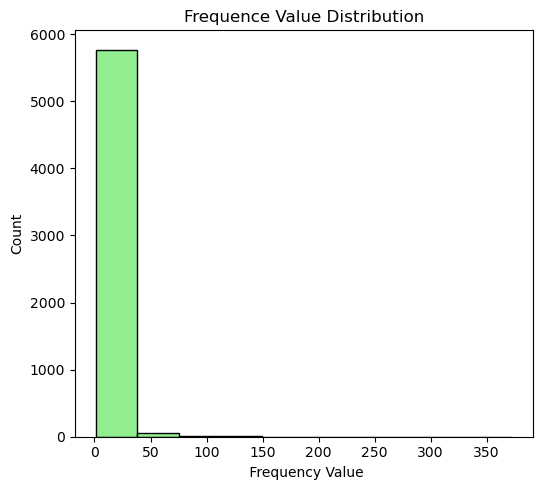

In [46]:
# Frequence Value Distribution
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(rfm["Frequency"],bins=10,color="lightgreen",edgecolor="black")
plt.title("Frequence Value Distribution")
plt.xlabel(" Frequency Value")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

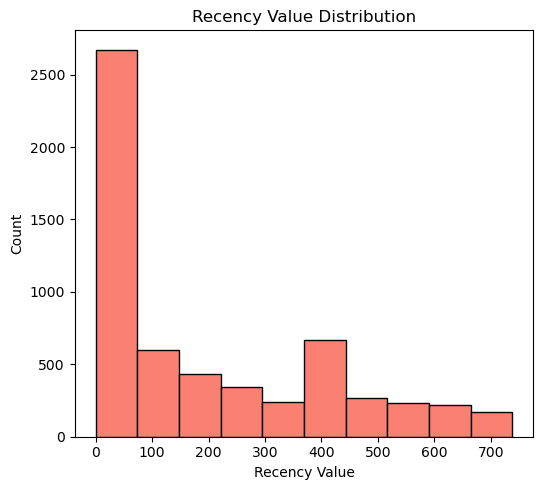

In [47]:
# Recency Value Distribution
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.hist(rfm["Recency"],bins=10,color="salmon",edgecolor="black")
plt.title("Recency Value Distribution")
plt.xlabel("Recency Value")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

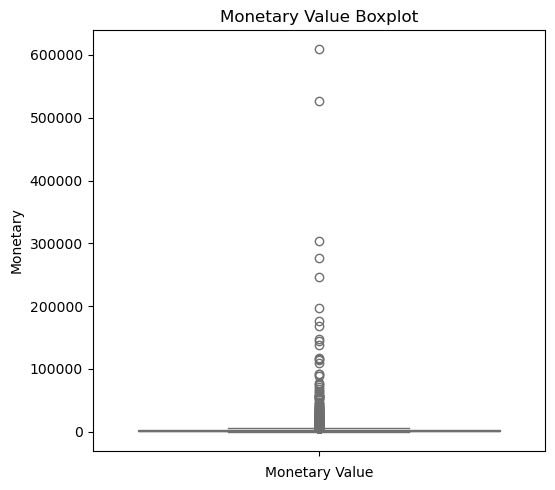

In [52]:
#check the distribution of outliers by using box plot
plt.figure(figsize=(15,5))
# Monetary Value 
plt.subplot(1,3,1)
sns.boxplot(data=rfm["Monetary"],color="skyblue")
plt.title("Monetary Value Boxplot")
plt.xlabel("Monetary Value")

plt.tight_layout()
plt.show()

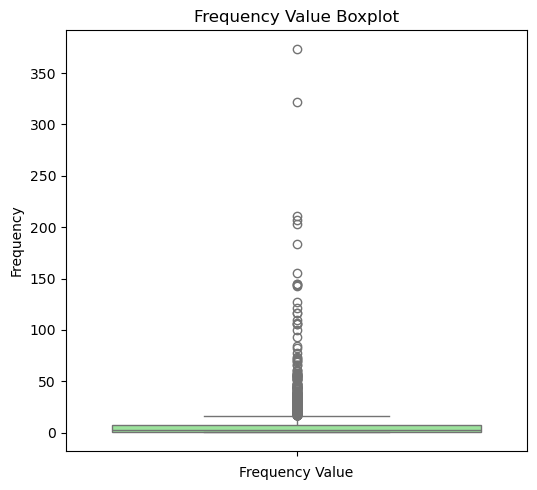

In [49]:
plt.figure(figsize=(15,5))
# Frequency Value 
plt.subplot(1,3,1)
sns.boxplot(data=rfm["Frequency"],color="lightgreen")
plt.title("Frequency Value Boxplot")
plt.xlabel("Frequency Value")

plt.tight_layout()
plt.show()

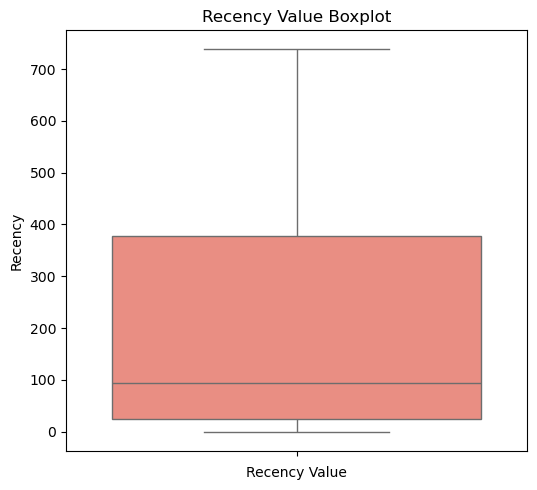

In [ ]:
plt.figure(figsize=(15,5))
#  Recency Value 
plt.subplot(1,3,1)
sns.boxplot(data=rfm["Recency"],color="salmon")
plt.title("Recency Value Boxplot")
plt.xlabel("Recency Value")

plt.tight_layout()
plt.show()

Above from kmean and below rfm

In [24]:
#Define quantiles
quantiles= rfm.quantile(q=[0.25,0.50,0.75])

#Assign RFM Scores
def rfmscore(x,p,d):
    if p=='Recency':
        if x <= d[p] [0.25]:
            return 4
        elif x <= d[p] [0.50]:
            return 3
        elif x <= d[p] [0.75]:
            return 2
        else:
            return 1
    else:
        if x <= d[p] [0.25]:
            return 1
        elif x <= d[p] [0.50]:
            return 2
        elif x <= d[p] [0.75]:
            return 3
        else:
            return 4
        
rfm['R'] = rfm['Recency'].apply(rfmscore, args=('Recency',quantiles,))
rfm['F'] = rfm['Frequency'].apply(rfmscore, args=('Frequency',quantiles,))
rfm['M'] = rfm['Monetary'].apply(rfmscore, args=('Monetary',quantiles,))

        
rfm.head()

       

,Customer ID,Monetary,Frequency,LastInvoiceDate,Recency,R,F,M
0,12346.0,77352.96,3,2011-01-18 10:01:00,325,2,2,4
1,12347.0,5633.32,8,2011-12-07 15:52:00,1,4,4,4
2,12348.0,1658.40,5,2011-09-25 13:13:00,74,3,3,3
3,12349.0,3678.69,3,2011-11-21 09:51:00,18,4,2,4
4,12350.0,294.40,1,2011-02-02 16:01:00,309,2,1,1


In [25]:
rfm['RFM_Segment'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm['RFM_Score'] = rfm[['R','F','M']].sum(axis=1)

In [26]:
rfm.head()

,Customer ID,Monetary,Frequency,LastInvoiceDate,Recency,R,F,M,RFM_Segment,RFM_Score
0,12346.0,77352.96,3,2011-01-18 10:01:00,325,2,2,4,224,8
1,12347.0,5633.32,8,2011-12-07 15:52:00,1,4,4,4,444,12
2,12348.0,1658.40,5,2011-09-25 13:13:00,74,3,3,3,333,9
3,12349.0,3678.69,3,2011-11-21 09:51:00,18,4,2,4,424,10
4,12350.0,294.40,1,2011-02-02 16:01:00,309,2,1,1,211,4


In [27]:
Segment_labels=['Champion','Loyal','New customer','Mid-tire','At risk','Lost']
def assign_segment(row):
    score = row['RFM_Score']
    f_score = row['F']
    if score >=10:
        return 'Champion'
    elif 8 <= score >=10:
        return 'Loyal'
    elif 6 <= score <=8:
        if f_score == 1:
            return 'New customer'
        else: 
            return 'Mid-tire'
    elif 4 <= score <=6:
        return 'At risk'
    else:
        return'Lost'
rfm['RFM_Segment_label'] = rfm.apply(assign_segment, axis=1)
rfm.head()

,Customer ID,Monetary,Frequency,LastInvoiceDate,Recency,R,F,M,RFM_Segment,RFM_Score,RFM_Segment_label
0,12346.0,77352.96,3,2011-01-18 10:01:00,325,2,2,4,224,8,Mid-tire
1,12347.0,5633.32,8,2011-12-07 15:52:00,1,4,4,4,444,12,Champion
2,12348.0,1658.40,5,2011-09-25 13:13:00,74,3,3,3,333,9,Lost
3,12349.0,3678.69,3,2011-11-21 09:51:00,18,4,2,4,424,10,Champion
4,12350.0,294.40,1,2011-02-02 16:01:00,309,2,1,1,211,4,At risk


In [28]:
segment_counts = rfm['RFM_Segment_label'].value_counts().reset_index()
segment_counts.columns = ['RFM_Segment','Count']
segment_counts = segment_counts.sort_values('RFM_Segment')
segment_counts.sort_index()

,RFM_Segment,Count
0,Champion,1646
1,Mid-tire,1639
2,At risk,1176
3,Lost,1145
4,New customer,246


In [29]:
#Create the bsr chart using plotly
fig = px.bar(segment_counts,
             x='RFM_Segment',
             y='Count',
             title='Customer Distribution by RFM Segment',
             labels={'RFM_Segment':'RFM segment','Count':'Number of Customers'},
             color= 'RFM_Segment',
             color_discrete_sequence=px.colors.qualitative.Pastel
             )
fig.show()

In [30]:
champion_segment= rfm[rfm['RFM_Segment_label']=='Champion']


In [31]:
#Box plot for champion 
fig = go.Figure()
fig.add_trace(go.Box(y=champion_segment['Recency'], name='Recency'))
fig.add_trace(go.Box(y=champion_segment['Frequency'], name='Frequency'))
fig.add_trace(go.Box(y=champion_segment['Monetary'], name='Monetary'))


In [32]:
correlation_matrix = champion_segment[['R','F','M']].corr()
correlation_matrix

,R,F,M
R,1.000000,-0.182082,-0.217589
F,-0.182082,1.000000,0.356715
M,-0.217589,0.356715,1.000000


In [33]:
#create heatmap for champion correlation
fig_heatmap = go.Figure(data=go.Heatmap(
    z=correlation_matrix.values,
    x=correlation_matrix.columns,
    y=correlation_matrix.columns,
    colorscale='RdBu',
    colorbar=dict(title='Correlation')
))
fig_heatmap.update_layout(title='Corrlation Martix of RFM Values within Champions Segment')
fig_heatmap.show()

In [34]:
# bar plot
pastel_colors= plotly.colors.qualitative.Pastel
fig=go.Figure(data=[go.Bar(x=segment_counts.index, y=segment_counts.values,
                           marker=dict(color=pastel_colors))])
vip_color = 'rgb(158,202,225)'
fig.update_traces(marker_color=[vip_color if segment == 'Champions' else pastel_colors[i]
                                for i, segment in enumerate(segment_counts.index)],
                  marker_line_color='rgb(8,48,107)',
                  marker_line_width=1.5, opacity=0.6)
#Update the layout
fig.update_layout(title='Comparision of RFM Segments',
                  xaxis_title='RFM Segments',
                  yaxis_title='Number of Customers',
                  showlegend=False)
fig.show()

In [35]:
segment_scores = rfm.groupby('RFM_Segment_label')[['R','F','M']].mean().reset_index()
fig=go.Figure()

#Add bars for Recency score
fig.add_trace(go.Bar(
    x=segment_scores['RFM_Segment_label'],
    y=segment_scores['R'],
    name='Recency Score',
    marker_color='rgb(158,202,225)'
)) 

#Add bars for Frequency score
fig.add_trace(go.Bar(
    x=segment_scores['RFM_Segment_label'],
    y=segment_scores['F'],
    name='Frequency Score',
    marker_color='rgb(94,158,217)'
)) 

#Add bars for Monetary score
fig.add_trace(go.Bar(
    x=segment_scores['RFM_Segment_label'],
    y=segment_scores['M'],
    name='Monetary Score',
    marker_color='rgb(32,102,148)'
)) 

# Update the layout
fig.update_layout(
    title='Comparision of RFM Segments based on Recency, Frequency, and Monetary Scores',
    xaxis_title='RFM Segments',
    yaxis_title='Score',
    barmode='group',
    showlegend=True
)
fig.show()

In [36]:
rfm.to_csv('rfm_data.csv',index=False)